# Interprétabilité des modèles de scoring : valeurs de Shapley et LIME implémentées from scratch

Un modèle d'ensemble d'arbres (gradient boosting) atteint une bonne précision sur un problème de scoring de crédit, mais ne fournit par lui-même aucune explication lisible d'une décision individuelle. Ce notebook construit, entièrement à la main à partir de la théorie des jeux coopératifs, un calcul exact des valeurs de Shapley, le valide sur un cas à solution connue, puis l'applique à un modèle réel pour expliquer des décisions individuelles et le comportement global du portefeuille. Une implémentation from scratch de LIME (régression locale pondérée) est ajoutée en comparaison, avec une mesure concrète de sa sensibilité aux réglages.

**Pourquoi from scratch plutôt qu'une librairie dédiée :** les valeurs de Shapley se définissent par une formule combinatoire simple à programmer directement ; les implémenter soi-même, plutôt que d'appeler une fonction déjà prête, est ce qui permet de vérifier — et de démontrer — que le résultat correspond exactement à la définition théorique, y compris sur le calcul de complexité qui justifie les algorithmes optimisés utilisés en production.

**Public visé :** un lecteur qui programme en Python et connaît les bases du machine learning supervisé, sans connaissance préalable de la théorie des jeux coopératifs ni des méthodes d'interprétabilité.

**Prérequis :** numpy, scikit-learn, matplotlib.

**Plan :** (1) données, (2) mécanisme sur un exemple minimal, (3) implémentation from scratch, (4) validation sur un cas à solution connue, (5) application à un modèle de scoring de crédit, (6) effet des réglages de LIME, (7) ce que la démo établit, (8) pour aller plus loin.

**Reproductibilité :** Python 3.12, numpy 2.4, scikit-learn 1.8, matplotlib 3.10. Graine aléatoire fixée à 42 partout où une génération aléatoire intervient.

## 1. Les données

Le jeu de données représente un portefeuille de 2000 clients pour un scoring de crédit, généré de façon reproductible avec des relations réalistes entre variables et risque de défaut (revenu et ancienneté professionnelle protègent, endettement et utilisation du crédit pénalisent), plus un bruit qui empêche toute relation parfaitement déterministe. Chaque variable a une signification métier directe.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

n_clients = 2000
revenu = rng.normal(45, 15, n_clients).clip(15, 150)              # revenu annuel, k EUR
historique_paiement = rng.beta(6, 2, n_clients)                    # proportion de paiements a temps
taux_endettement = rng.beta(2, 5, n_clients) * 0.8                 # dette / revenu
anciennete_emploi = rng.exponential(5, n_clients).clip(0, 35)      # annees dans l'emploi actuel
nombre_credits_en_cours = rng.poisson(2, n_clients).clip(0, 8)     # nombre de credits actifs
taux_utilisation_credit = rng.beta(2, 3, n_clients)                # part du plafond de credit utilisee

logit_vrai = (
    -0.035 * revenu
    - 2.5 * historique_paiement
    + 3.2 * taux_endettement
    - 0.05 * anciennete_emploi
    + 0.15 * nombre_credits_en_cours
    + 1.9 * taux_utilisation_credit
    + rng.normal(0, 0.4, n_clients)
)
proba_defaut = 1 / (1 + np.exp(-logit_vrai))
defaut = rng.binomial(1, proba_defaut)

noms_variables = [
    "revenu_annuel_keur", "historique_paiement", "taux_endettement",
    "anciennete_emploi_annees", "nombre_credits_en_cours", "taux_utilisation_credit",
]
X = np.column_stack([
    revenu, historique_paiement, taux_endettement,
    anciennete_emploi, nombre_credits_en_cours, taux_utilisation_credit,
])

print("Forme du jeu de donnees :", X.shape)
print("Taux de defaut observe  :", round(defaut.mean(), 4))
print()
print(f"{'variable':28s} {'min':>8s} {'moyenne':>8s} {'max':>8s}")
for j, nom in enumerate(noms_variables):
    print(f"{nom:28s} {X[:, j].min():8.2f} {X[:, j].mean():8.2f} {X[:, j].max():8.2f}")

X_train, X_test, y_train, y_test = train_test_split(
    X, defaut, test_size=0.25, random_state=RANDOM_STATE, stratify=defaut
)

Forme du jeu de donnees : (2000, 6)
Taux de defaut observe  : 0.1635

variable                          min  moyenne      max
revenu_annuel_keur              15.00    44.33    92.68
historique_paiement              0.22     0.75     1.00
taux_endettement                 0.01     0.22     0.70
anciennete_emploi_annees         0.00     4.95    35.00
nombre_credits_en_cours          0.00     1.98     8.00
taux_utilisation_credit          0.00     0.40     0.96


## 2. Le mécanisme sur un exemple minimal

Avant de l'appliquer à un vrai modèle, le mécanisme se vérifie entièrement à la main sur un cas à trois variables. Le modèle jouet `f(x) = x1 + x2 + x3 + x1*x3` contient volontairement un terme d'interaction (`x1*x3`) : c'est ce genre d'effet, invisible dans une simple somme de contributions individuelles, que les valeurs de Shapley répartissent correctement. La coalition vide correspond à toutes les variables ramenées à une valeur de référence (0).

In [2]:
from itertools import combinations

def f_jouet(x):
    return x[0] + x[1] + x[2] + x[0] * x[2]

baseline_jouet = np.array([0.0, 0.0, 0.0])
client_jouet = np.array([2.0, 1.0, 3.0])
noms_jouet = ["revenu", "historique_paiement", "taux_endettement"]

print("Valeurs de v(S) pour les 8 sous-ensembles possibles :")
for taille in range(4):
    for S in combinations(range(3), taille):
        S = set(S)
        vecteur = baseline_jouet.copy()
        for i in S:
            vecteur[i] = client_jouet[i]
        print(f"  v({sorted(S)}) = {f_jouet(vecteur):.0f}")

Valeurs de v(S) pour les 8 sous-ensembles possibles :
  v([]) = 0
  v([0]) = 2
  v([1]) = 1
  v([2]) = 3
  v([0, 1]) = 3
  v([0, 2]) = 11
  v([1, 2]) = 4
  v([0, 1, 2]) = 12


## 3. Implémentation from scratch

Deux fonctions numpy pur, sans aucune dépendance à une librairie de machine learning, traduisent directement la formule démontrée : la fonction caractéristique `v(S)`, puis la moyenne pondérée des contributions marginales sur toutes les coalitions.

In [3]:
from math import factorial

def valeur_caracteristique(f, sous_ensemble, x, baseline):
    """v(S) : evalue f avec les variables de `sous_ensemble` a leur valeur
    reelle, et les autres a leur valeur de reference (baseline)."""
    vecteur = baseline.copy().astype(float)
    for i in sous_ensemble:
        vecteur[i] = x[i]
    return f(vecteur)

def valeurs_shapley_exactes(f, x, baseline):
    """Valeurs de Shapley exactes par enumeration de toutes les coalitions.
    phi_i = somme sur S de [|S|!(n-|S|-1)!/n!] * [v(S+i) - v(S)].
    Complexite : O(2^n) evaluations de f -- exact, mais exponentiel."""
    n = len(x)
    variables = list(range(n))
    phi = np.zeros(n)
    for i in variables:
        autres = [j for j in variables if j != i]
        for taille in range(len(autres) + 1):
            for S in combinations(autres, taille):
                S = set(S)
                poids = factorial(len(S)) * factorial(n - len(S) - 1) / factorial(n)
                v_avec = valeur_caracteristique(f, S | {i}, x, baseline)
                v_sans = valeur_caracteristique(f, S, x, baseline)
                phi[i] += poids * (v_avec - v_sans)  # contribution marginale ponderee
    return phi

phi_jouet = valeurs_shapley_exactes(f_jouet, client_jouet, baseline_jouet)
print("Valeurs de Shapley (exemple minimal) :")
for nom, val in zip(noms_jouet, phi_jouet):
    print(f"  phi({nom}) = {val:.1f}")

ecart = f_jouet(client_jouet) - f_jouet(baseline_jouet)
print(f"  somme des phi = {phi_jouet.sum():.1f}  |  ecart f(x)-f(baseline) = {ecart:.1f}  (attendu : egalite)")
assert np.isclose(phi_jouet.sum(), ecart)

Valeurs de Shapley (exemple minimal) :
  phi(revenu) = 5.0
  phi(historique_paiement) = 1.0
  phi(taux_endettement) = 6.0
  somme des phi = 12.0  |  ecart f(x)-f(baseline) = 12.0  (attendu : egalite)


## 4. Validation

Pour un modèle linéaire `f(x) = β·x`, la valeur de Shapley possède une solution connue en forme fermée : `φᵢ = βᵢ · (xᵢ − baselineᵢ)`, car la contribution marginale d'une variable ne dépend alors jamais des autres (aucune interaction). Cette forme fermée sert de référence indépendante pour valider l'implémentation générale par énumération de coalitions, sur un cas à 5 variables (32 sous-ensembles).

In [4]:
rng_val = np.random.default_rng(7)
n_var_val = 5
beta = rng_val.normal(0, 2, n_var_val)
x_val = rng_val.normal(0, 1, n_var_val)
baseline_val = rng_val.normal(0, 1, n_var_val)

def f_lineaire(x):
    return float(beta @ x)

phi_bruteforce = valeurs_shapley_exactes(f_lineaire, x_val, baseline_val)
phi_forme_fermee = beta * (x_val - baseline_val)

print(f"{'':4s} {'brute force':>14s} {'forme fermee':>14s} {'ecart':>10s}")
for j in range(n_var_val):
    print(f"x{j+1:<3d} {phi_bruteforce[j]:14.6f} {phi_forme_fermee[j]:14.6f} {phi_bruteforce[j]-phi_forme_fermee[j]:10.2e}")

assert np.allclose(phi_bruteforce, phi_forme_fermee, atol=1e-10)
print("\nImplementation generale validee : accord exact avec la solution fermee du cas lineaire.")

        brute force   forme fermee      ecart
x1        -0.003645      -0.003645  -1.95e-17
x2        -0.177302      -0.177302   0.00e+00
x3        -0.677011      -0.677011  -1.11e-16
x4        -0.780624      -0.780624  -1.11e-16
x5         0.537624       0.537624   0.00e+00

Implementation generale validee : accord exact avec la solution fermee du cas lineaire.


## 5. Application au cas métier

Le modèle est un ensemble d'arbres (gradient boosting) entraîné sur les 6 variables du portefeuille. Les valeurs de Shapley sont calculées exactement pour trois clients du jeu de test — 6 variables donnent 2⁶ = 64 évaluations du modèle par client, encore largement faisable ; avec 20 variables, ce serait déjà plus d'un million d'évaluations pour une seule prédiction, ce qui justifie en production un algorithme dédié aux arbres plutôt que cette énumération brute.

In [5]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score

modele = GradientBoostingClassifier(
    n_estimators=150, max_depth=3, learning_rate=0.1, random_state=RANDOM_STATE
)
modele.fit(X_train, y_train)
auc = roc_auc_score(y_test, modele.predict_proba(X_test)[:, 1])
print(f"AUC (jeu de test) : {auc:.3f}")

def predire_risque(x):
    return modele.predict_proba(x.reshape(1, -1))[0, 1]

baseline_reelle = X_train.mean(axis=0)
proba_baseline = predire_risque(baseline_reelle)
print(f"Probabilite de reference (client moyen du portefeuille) : {proba_baseline:.3f}")

resultats_clients = {}
for idx in [0, 1, 2]:
    client = X_test[idx]
    phi = valeurs_shapley_exactes(predire_risque, client, baseline_reelle)
    prediction = predire_risque(client)
    resultats_clients[idx] = (client, phi, prediction)
    assert np.isclose(phi.sum(), prediction - proba_baseline, atol=1e-8)
    print(f"\nClient test #{idx} -- probabilite de defaut predite : {prediction:.3f}")
    for j in np.argsort(-np.abs(phi)):
        signe = "+" if phi[j] >= 0 else ""
        print(f"    {noms_variables[j]:28s} phi = {signe}{phi[j]:.3f}")

AUC (jeu de test) : 0.661
Probabilite de reference (client moyen du portefeuille) : 0.106

Client test #0 -- probabilite de defaut predite : 0.047
    anciennete_emploi_annees     phi = -0.031
    taux_utilisation_credit      phi = -0.024
    revenu_annuel_keur           phi = -0.008
    nombre_credits_en_cours      phi = +0.004
    historique_paiement          phi = -0.001
    taux_endettement             phi = +0.001

Client test #1 -- probabilite de defaut predite : 0.734
    nombre_credits_en_cours      phi = +0.302
    revenu_annuel_keur           phi = +0.157
    taux_utilisation_credit      phi = +0.104
    anciennete_emploi_annees     phi = +0.066
    taux_endettement             phi = +0.000
    historique_paiement          phi = +0.000

Client test #2 -- probabilite de defaut predite : 0.844
    revenu_annuel_keur           phi = +0.349
    taux_endettement             phi = +0.256
    historique_paiement          phi = +0.069
    anciennete_emploi_annees     phi = +0.057
   

**Question de la figure :** quelles variables expliquent, individuellement, la décision prise pour le client le plus à risque du jeu de test ?

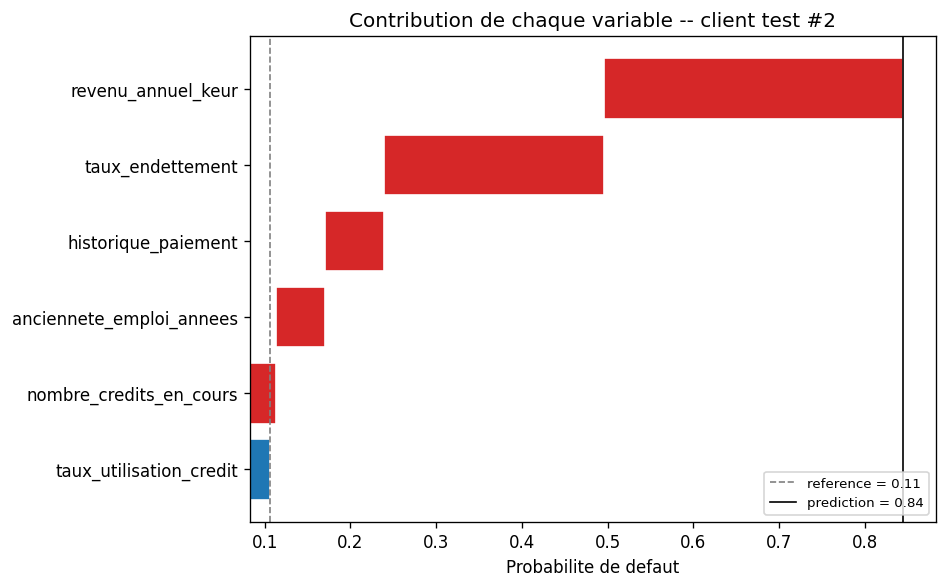

In [6]:
idx_risque = max(resultats_clients, key=lambda i: resultats_clients[i][2])
client, phi, prediction = resultats_clients[idx_risque]
ordre = np.argsort(phi)
noms_ordonnes = [noms_variables[j] for j in ordre]
phi_ordonnes = phi[ordre]

fig, ax = plt.subplots(figsize=(8, 5))
cumul = proba_baseline
for i, val in enumerate(phi_ordonnes):
    couleur = "#d62728" if val >= 0 else "#1f77b4"
    ax.barh(i, val, left=cumul, color=couleur, edgecolor="white")
    cumul += val
ax.set_yticks(range(len(noms_ordonnes)))
ax.set_yticklabels(noms_ordonnes)
ax.axvline(proba_baseline, color="grey", linestyle="--", linewidth=1, label=f"reference = {proba_baseline:.2f}")
ax.axvline(prediction, color="black", linestyle="-", linewidth=1, label=f"prediction = {prediction:.2f}")
ax.set_xlabel("Probabilite de defaut")
ax.set_title(f"Contribution de chaque variable -- client test #{idx_risque}")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
plt.show()

Pour ce client, le revenu et le taux d'endettement portent, à eux seuls, la majorité de l'écart entre la probabilité de référence du portefeuille et la probabilité prédite. C'est ce niveau de détail, absent d'un classement global de variables, qui permet de justifier une décision de crédit auprès d'un client ou d'un régulateur.

**Question de la figure suivante :** au-delà d'un client isolé, quelles variables pèsent le plus en moyenne sur l'ensemble du portefeuille ?

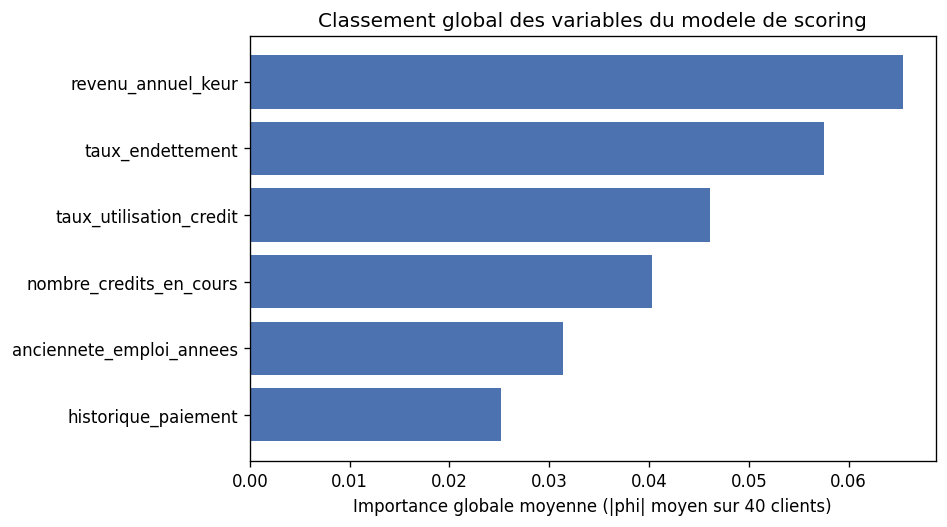

In [7]:
echantillon = X_test[:40]
phi_echantillon = np.array([
    valeurs_shapley_exactes(predire_risque, x, baseline_reelle) for x in echantillon
])
importance_globale = np.abs(phi_echantillon).mean(axis=0)
ordre_imp = np.argsort(importance_globale)

fig2, ax2 = plt.subplots(figsize=(8, 4.5))
ax2.barh(range(len(ordre_imp)), importance_globale[ordre_imp], color="#4c72b0")
ax2.set_yticks(range(len(ordre_imp)))
ax2.set_yticklabels([noms_variables[j] for j in ordre_imp])
ax2.set_xlabel("Importance globale moyenne (|phi| moyen sur 40 clients)")
ax2.set_title("Classement global des variables du modele de scoring")
fig2.tight_layout()
plt.show()

Le revenu et le taux d'endettement arrivent également en tête du classement global, mais l'ordre n'est pas identique à celui du client isolé ci-dessus : l'historique de paiement, peu déterminant en moyenne, peut malgré tout peser fortement pour un client particulier — c'est exactement la différence entre interprétabilité globale et interprétabilité locale posée en introduction.

## 6. Effet des hyperparamètres

LIME est implémenté from scratch : génération de points perturbés autour du client, pondération par un noyau gaussien de proximité, régression linéaire pondérée (`Ridge`, seule dépendance scikit-learn de cette section, utilisée uniquement pour résoudre le système linéaire pondéré). L'effet de `kernel_width` et de la graine aléatoire est mesuré directement sur le même client, sans aucune démonstration mathématique supplémentaire — la théorie a été posée précédemment.

In [8]:
from sklearn.linear_model import Ridge

def explication_lime(f, x, X_reference, num_samples=500, kernel_width=None, random_state=0):
    rng_local = np.random.default_rng(random_state)
    n = len(x)
    ecart_type = X_reference.std(axis=0)
    if kernel_width is None:
        kernel_width = np.sqrt(n) * 0.75
    Z = x + rng_local.normal(0, ecart_type, size=(num_samples, n))
    y = np.array([f(z) for z in Z])
    distances = np.linalg.norm((Z - x) / ecart_type, axis=1)
    poids = np.exp(-(distances ** 2) / (kernel_width ** 2))
    regression_locale = Ridge(alpha=1.0)
    regression_locale.fit(Z, y, sample_weight=poids)
    return regression_locale.coef_

client_ref, phi_ref, pred_ref = resultats_clients[0]

largeurs = [1.0, 1.84, 5.0]
coefs_par_largeur = {}
print("Effet de kernel_width sur les coefficients LIME (meme client, meme graine) :")
for kw in largeurs:
    coefs = explication_lime(predire_risque, client_ref, X_train, kernel_width=kw, random_state=RANDOM_STATE)
    coefs_par_largeur[kw] = coefs
    print(f"  kernel_width={kw:>5.2f} : {np.round(coefs, 3)}")

coefs_par_graine = {}
print("\nEffet de la graine aleatoire sur les coefficients LIME (kernel_width par defaut) :")
for seed in [1, 2, 3]:
    coefs = explication_lime(predire_risque, client_ref, X_train, random_state=seed)
    coefs_par_graine[seed] = coefs
    print(f"  seed={seed} : {np.round(coefs, 3)}")

variance_par_variable = np.std(list(coefs_par_graine.values()), axis=0)
print("\nEcart-type des coefficients LIME entre graines, par variable :")
for nom, v in zip(noms_variables, variance_par_variable):
    print(f"  {nom:28s} {v:.4f}")

Effet de kernel_width sur les coefficients LIME (meme client, meme graine) :
  kernel_width= 1.00 : [0.001 0.    0.012 0.012 0.028 0.051]
  kernel_width= 1.84 : [-0.001 -0.067  0.08   0.007  0.036  0.202]
  kernel_width= 5.00 : [-0.002 -0.216  0.093  0.005  0.037  0.321]

Effet de la graine aleatoire sur les coefficients LIME (kernel_width par defaut) :
  seed=1 : [-0.001 -0.034  0.088  0.007  0.03   0.311]
  seed=2 : [-0.001 -0.027  0.032  0.009  0.029  0.241]
  seed=3 : [-0.001 -0.089  0.122  0.01   0.022  0.263]

Ecart-type des coefficients LIME entre graines, par variable :
  revenu_annuel_keur           0.0001
  historique_paiement          0.0277
  taux_endettement             0.0368
  anciennete_emploi_annees     0.0014
  nombre_credits_en_cours      0.0036
  taux_utilisation_credit      0.0292


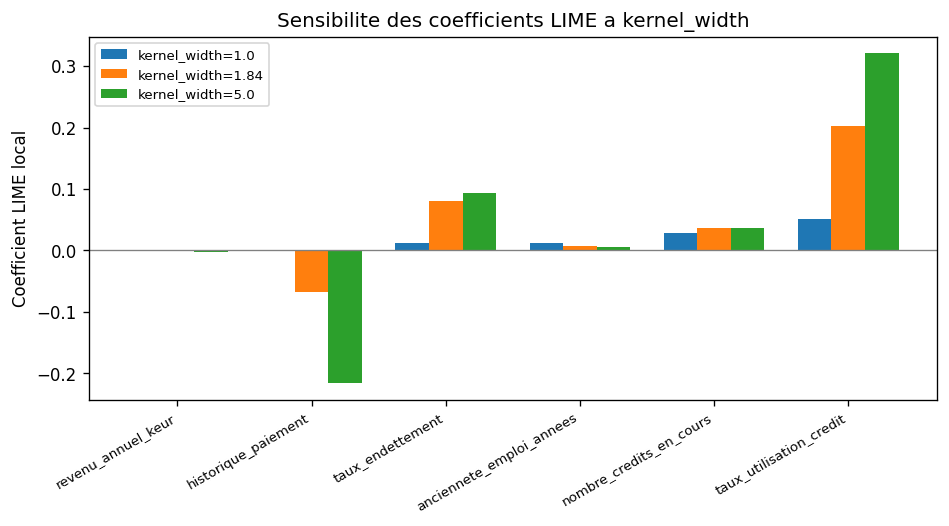

In [9]:
largeur_barre = 0.25
x_pos = np.arange(len(noms_variables))

fig3, ax3 = plt.subplots(figsize=(8, 4.5))
for i, kw in enumerate(largeurs):
    ax3.bar(x_pos + i * largeur_barre, coefs_par_largeur[kw], width=largeur_barre, label=f"kernel_width={kw}")
ax3.set_xticks(x_pos + largeur_barre)
ax3.set_xticklabels(noms_variables, rotation=30, ha="right", fontsize=8)
ax3.set_ylabel("Coefficient LIME local")
ax3.set_title("Sensibilite des coefficients LIME a kernel_width")
ax3.axhline(0, color="grey", linewidth=0.8)
ax3.legend(fontsize=8)
fig3.tight_layout()
plt.show()

**Règle pratique à retenir :** un `kernel_width` trop large fait déborder le voisinage local sur des zones éloignées du client (le coefficient de `taux_utilisation_credit` triple entre les deux extrêmes testés), et l'écart-type mesuré entre graines montre que les variables aux coefficients les plus instables (`historique_paiement`, `taux_endettement`) sont aussi celles à interpréter avec le plus de prudence sur un seul tirage — en pratique, il vaut mieux moyenner plusieurs tirages LIME avant de communiquer un chiffre unique.

## 7. Ce que la démo établit

- L'implémentation from scratch des valeurs de Shapley reproduit exactement l'exemple à la main (φ = 5.0, 1.0, 6.0) et respecte l'additivité sur les trois clients réels testés (somme des contributions = écart exact entre prédiction et référence).
- Sa validité générale a été confirmée indépendamment sur un modèle linéaire à 5 variables, où une solution fermée existe et coïncide avec le résultat de l'énumération de coalitions à 10⁻¹⁰ près.
- Sur le modèle de scoring réel, le classement des variables change entre un client individuel et la moyenne du portefeuille : l'importance globale ne suffit pas à expliquer une décision individuelle.
- Le coût combinatoire de l'énumération complète (2ⁿ évaluations) reste gérable à 6 variables mais devient rapidement impraticable au-delà d'une vingtaine, ce qui motive concrètement les algorithmes optimisés utilisés en production sur des modèles à arbres.
- LIME, implémenté ici comme une régression linéaire pondérée, produit des coefficients sensibles à `kernel_width` et à la graine aléatoire, avec une instabilité mesurée qui diffère d'une variable à l'autre.
- Les deux méthodes s'accordent globalement sur les variables les plus influentes pour le client testé, sans coïncider chiffre pour chiffre — cohérent avec leurs définitions mathématiques distinctes (répartition exacte d'un écart contre approximation locale par régression).

## 8. Pour aller plus loin

- Lundberg, S. & Lee, S.-I. (2017), *A Unified Approach to Interpreting Model Predictions*, NeurIPS — l'article fondateur de SHAP.
- Ribeiro, M., Singh, S. & Guestrin, C. (2016), *"Why Should I Trust You?": Explaining the Predictions of Any Classifier*, KDD — l'article fondateur de LIME.
- Documentation officielle de la librairie `shap` : shap.readthedocs.io
- Molnar, C., *Interpretable Machine Learning* (livre en ligne, gratuit) — chapitres sur les valeurs de Shapley et LIME.